In [15]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [17]:
movies = {
    'title': [
        'Avatar',
        'Titanic',
        'Avengers Endgame',
        'Iron Man',
        'The Dark Knight',
        'Batman Begins',
        'Interstellar',
        'Inception',
        'Doctor Strange',
        'Thor Ragnarok'
    ],

    'genres': [
        'Action Adventure Sci-Fi',
        'Romance Drama',
        'Action Superhero',
        'Action Superhero',
        'Action Crime',
        'Action Crime',
        'Sci-Fi Drama',
        'Sci-Fi Thriller',
        'Action Fantasy',
        'Action Fantasy'
    ]
}

df = pd.DataFrame(movies)

df.head()

,title,genres
0,Avatar,Action Adventure Sci-Fi
1,Titanic,Romance Drama
2,Avengers Endgame,Action Superhero
3,Iron Man,Action Superhero
4,The Dark Knight,Action Crime


In [18]:
df.to_csv("movies.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [19]:
movies = pd.read_csv("movies.csv")

movies.head()

,title,genres
0,Avatar,Action Adventure Sci-Fi
1,Titanic,Romance Drama
2,Avengers Endgame,Action Superhero
3,Iron Man,Action Superhero
4,The Dark Knight,Action Crime


In [20]:
cv = CountVectorizer()

matrix = cv.fit_transform(movies['genres'])

In [21]:
similarity = cosine_similarity(matrix)

print(similarity.shape)

(10, 10)


In [22]:
def recommend(movie_name):

    movie_index = movies[movies.title == movie_name].index[0]

    distances = similarity[movie_index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x:x[1]
    )[1:6]

    print("Recommended Movies:\n")

    for movie in movie_list:
        print(movies.iloc[movie[0]].title)

In [23]:
recommend("Iron Man")

Recommended Movies:

Iron Man
The Dark Knight
Batman Begins
Doctor Strange
Thor Ragnarok


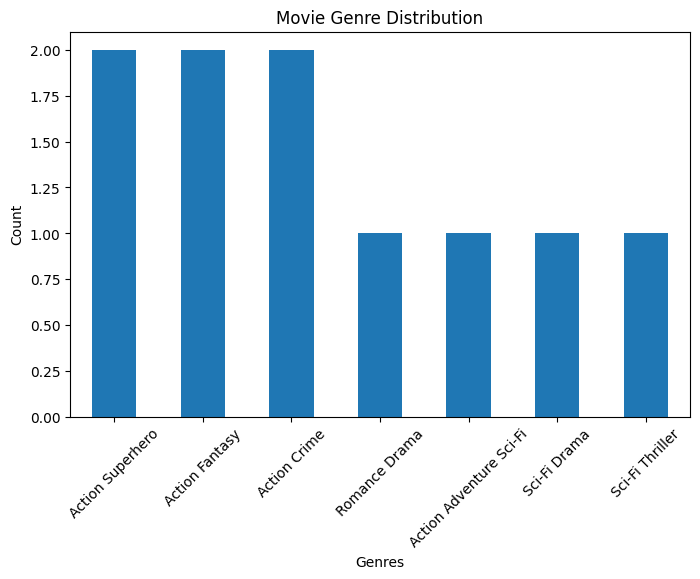

In [24]:
plt.figure(figsize=(8,5))

movies['genres'].value_counts().plot(
    kind='bar'
)

plt.title("Movie Genre Distribution")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

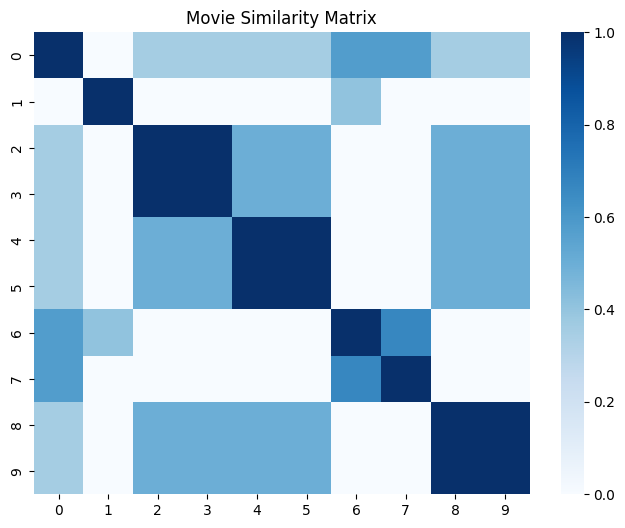

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    similarity,
    cmap='Blues'
)

plt.title("Movie Similarity Matrix")
plt.show()

In [27]:
movie_name = input("Enter Movie Name: ")

recommend(movie_name)

Enter Movie Name: Avatar
Recommended Movies:

Interstellar
Inception
Avengers Endgame
Iron Man
The Dark Knight
